In [1]:
import pytensor
pytensor.config.cxx = "/usr/bin/clang++"

import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pymc as pm
import arviz as az

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

---
## Load Data for Prior

In [30]:
past_vote_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="Past Vote", dtype={"FIPS" : str})
del past_vote_df["Weighted % D"]

In [31]:
statewide = past_vote_df[
    ["Total Votes Gov 2021 2P", "Murphy Votes", "RV 2021", "Total Votes GE 2024 2P", "Harris Votes", "RV 2024", "Current RV"]].sum()

In [32]:
statewide["County"] = "New Jersey"
statewide["FIPS"] = "34"

In [33]:
statewide["% Murphy 2P"] = statewide["Murphy Votes"] / statewide["Total Votes Gov 2021 2P"]
statewide["% 2P Turnout 2021"] = statewide["Total Votes Gov 2021 2P"] / statewide["RV 2021"]
statewide["% Harris 2P"] = statewide["Harris Votes"] / statewide["Total Votes GE 2024 2P"]
statewide["% 2P Turnout 2024"] = statewide["Total Votes GE 2024 2P"] / statewide["RV 2024"]
statewide["Margin Murphy Harris"] = statewide["% Harris 2P"] - statewide["% Murphy 2P"]

In [34]:
past_vote_df = pandas.concat([past_vote_df, pandas.DataFrame([statewide])], ignore_index=True)

---
## Load Survey Data

In [45]:
survey_df = pandas.read_excel(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=xlsx",
    sheet_name="GE", parse_dates=["end_date"])

In [46]:
for col in ["Ciattarelli", "Sherrill", "Neither", "Undecided"]:
    survey_df[col + " Lower"] = survey_df[col] - survey_df["moe"]
    survey_df[col + " Lower"] = survey_df[col + " Lower"].apply(lambda x : 0 if x < 0 else x)
    survey_df[col + " Upper"] = survey_df[col] + survey_df["moe"]

In [47]:
survey_df["Sherrill 2P Lower"] = survey_df["Sherrill Lower"] / (survey_df["Ciattarelli Lower"] + survey_df["Sherrill Lower"])
survey_df["Sherrill 2P Upper"] = survey_df["Sherrill Upper"] / (survey_df["Ciattarelli Upper"] + survey_df["Sherrill Upper"])
survey_df["Sherrill 2P"] = survey_df["Sherrill 2P"] / 100

In [48]:
survey_df["Sample Size 2P Lower"] = (
    survey_df["sample_size"] - 
    ((survey_df["Neither Lower"] / 100) * survey_df["sample_size"]) -
    ((survey_df["Undecided Lower"] / 100) * survey_df["sample_size"])).round(0)

In [49]:
survey_df["Sample Size 2P Upper"] = (
    survey_df["sample_size"] - 
    ((survey_df["Neither Upper"] / 100) * survey_df["sample_size"]) -
    ((survey_df["Undecided Upper"] / 100) * survey_df["sample_size"])).round(0)

In [50]:
survey_df["Sherrill 2P Votes"] = (survey_df["Sherrill 2P"] * survey_df["Sample Size 2P"]).round(0)
survey_df["Sherrill 2P Votes Lower"] = (survey_df["Sherrill 2P Lower"] * survey_df["Sample Size 2P Lower"]).round(0)
survey_df["Sherrill 2P Votes Upper"] = (survey_df["Sherrill 2P Upper"] * survey_df["Sample Size 2P Upper"]).round(0)

In [51]:
id_cols = ["pollster", "end_date", "population", "mode", "moe", "Sample Size 2P"]

temp = survey_df.melt(id_vars=id_cols,
                      value_vars=["Sherrill 2P Votes", "Sherrill 2P Votes Lower", "Sherrill 2P Votes Upper"],
                      value_name="Votes")
temp["variable"] = temp["variable"].str.replace("Sherrill 2P Votes", "Survey")

temp2 = survey_df.melt(id_vars=id_cols,
                       value_vars=["Sherrill 2P", "Sherrill 2P Lower", "Sherrill 2P Upper"],
                       value_name="%")
temp2["variable"] = temp2["variable"].str.replace("Sherrill 2P", "Survey")

survey_votes_df = temp.merge(temp2, on=id_cols + ["variable"])

survey_votes_df["moe"] = survey_votes_df["moe"] / 100

survey_votes_df

,pollster,end_date,population,mode,moe,Sample Size 2P,variable,Votes,%
0,Rutgers-Eagleton,2025-06-16,rv,panel,0.052,473,Survey,294.0,0.621951
1,Rutgers-Eagleton,2025-06-16,rv,panel,0.052,473,Survey Lower,340.0,0.639665
2,Rutgers-Eagleton,2025-06-16,rv,panel,0.052,473,Survey Upper,251.0,0.608225


---
## Fit this State-Level "Model" For Now Because We Only Have One Survey So Far

In [52]:
with pm.Model() as state_model:
    # prior
    prior_pct_D = pm.Beta("prior_pct_D",
                          mu=statewide[["% Murphy 2P", "% Harris 2P"]].mean(),
                          sigma=statewide[["% Murphy 2P", "% Harris 2P"]].std(ddof=1))

    # poll results, two-party
    poll_pct_D = pm.Beta("poll_pct_D", mu=survey_votes_df["%"].mean(), sigma=survey_votes_df["moe"].mean())

    beta0 = pm.Normal("beta0", mu=0, sigma=1)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    pct_D = beta0 + (beta1 * prior_pct_D) + (beta2 * poll_pct_D)
    # pct_D = pm.math.invlogit(beta0 + prior_pct_D + poll_pct_D) # produces REALLY high estimates
    
    # likelihood
    y_hat = pm.Binomial(
        "y_hat",
        p=pct_D,
        n=survey_votes_df["Sample Size 2P"],
        observed=survey_votes_df["Votes"]
    )

In [53]:
with state_model:
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [prior_pct_D, poll_pct_D, beta0, beta1, beta2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


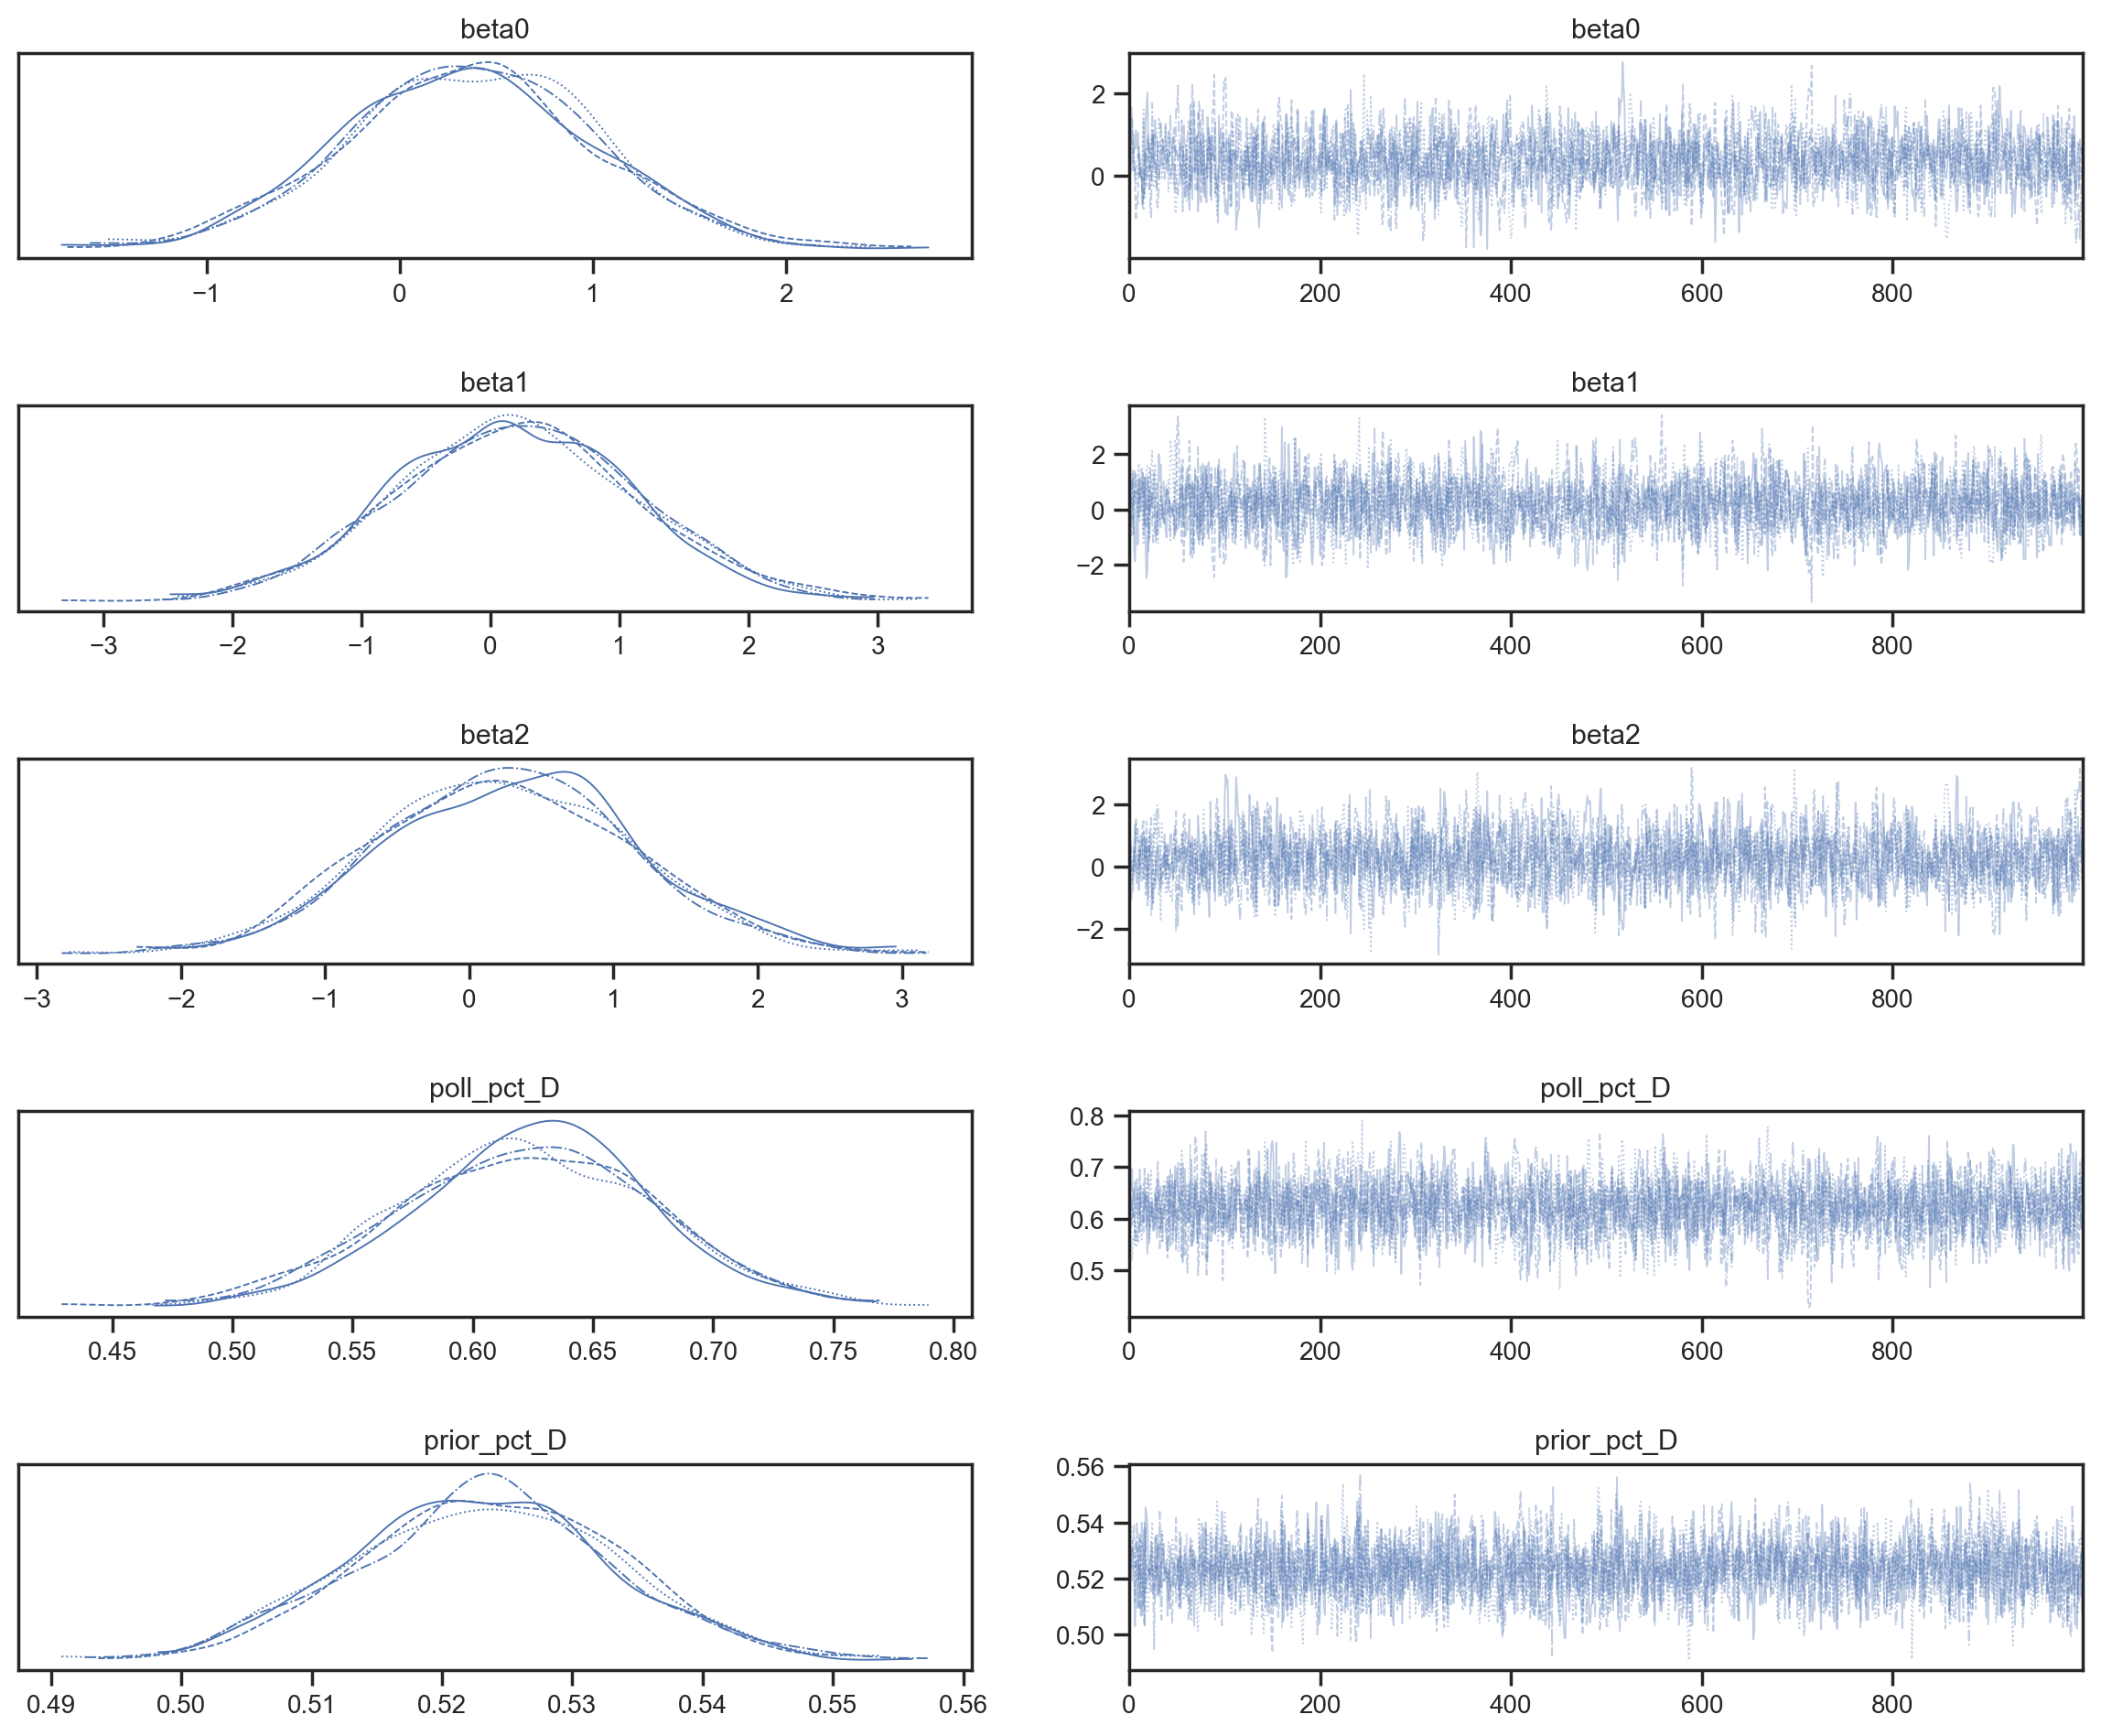

In [54]:
az.plot_trace(idata);
plt.tight_layout()

In [55]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.361,0.638,-0.830,1.571,0.014,0.011,2203.0,2013.0,1.0
beta1,0.193,0.930,-1.477,2.019,0.018,0.015,2527.0,2294.0,1.0
beta2,0.256,0.875,-1.317,1.941,0.018,0.016,2414.0,2051.0,1.0
poll_pct_D,0.623,0.052,0.524,0.720,0.001,0.001,3137.0,2067.0,1.0
prior_pct_D,0.523,0.010,0.505,0.541,0.000,0.000,3346.0,2569.0,1.0


In [56]:
with state_model:
    pred_oos_state = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

Sampling: [y_hat]


Output()

In [57]:
pred_oos_state["predictions"]["y_hat"].mean() / 473

<xarray.DataArray 'y_hat' ()> Size: 8B
array(0.62349877)

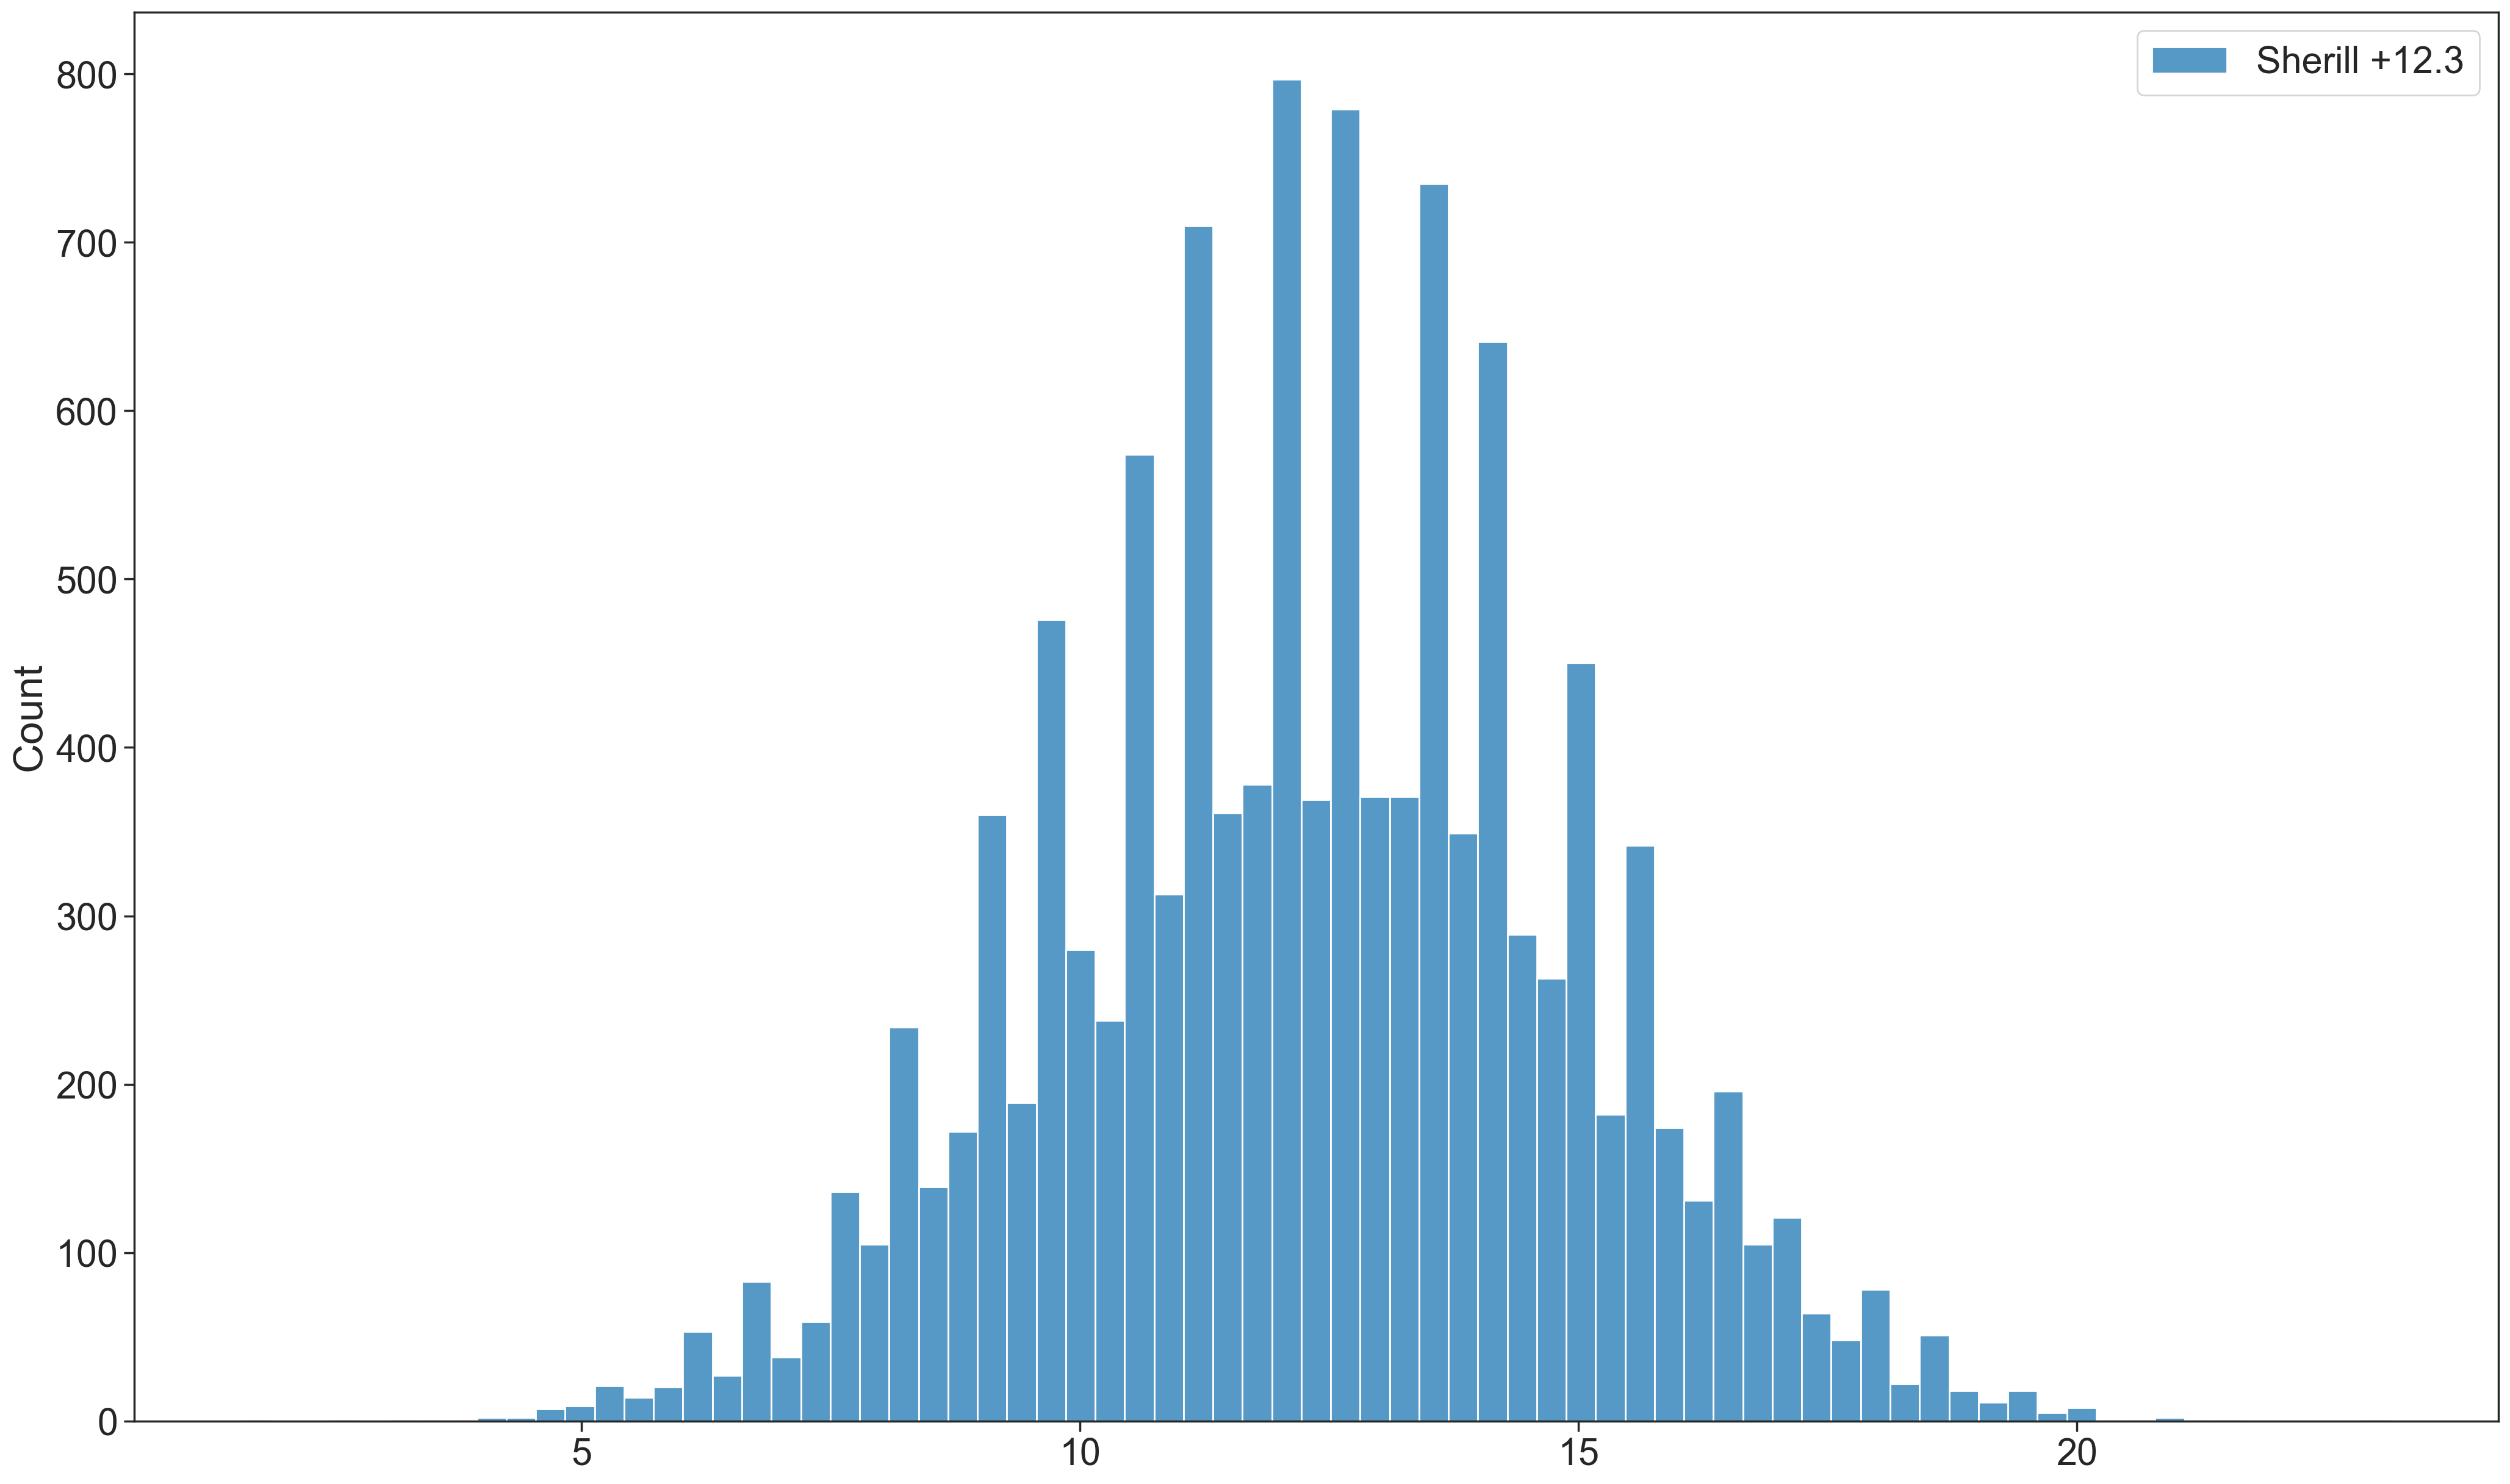

In [58]:
pred_pct_D = (pred_oos_state["predictions"]["y_hat"] / 473).stack(sample=("chain", "draw", "y_hat_dim_0")).values
pred_pct_D = (pred_pct_D - 0.5) * 100
ax = sns.histplot(x=pred_pct_D, color="tab:blue", label=f"Sherill +{np.round(pred_pct_D.mean(), 1)}")
ax.legend()
plt.show()

---

In [35]:
coords = {
    "county" : past_vote_df["County"]
}

In [36]:
with pm.Model(coords=coords) as model:
    turnout_pct = pm.Beta("turnout_pct",
                          mu=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].mean(axis=1),
                          sigma=past_vote_df[["% 2P Turnout 2021", "% 2P Turnout 2024"]].std(ddof=1, axis=1),
                          dims="county")

    turnout = pm.Binomial("turnout",
                          p=turnout_pct,
                          n=past_vote_df["Current RV"],
                          dims="county")

    prior_pct_D = pm.Beta("prior_pct_D",
                          mu=past_vote_df[["% Murphy 2P", "% Harris 2P"]].mean(axis=1),
                          sigma=past_vote_df[["% Murphy 2P", "% Harris 2P"]].std(ddof=1, axis=1),
                          dims="county")

    # prior_vote_D = pm.Deterministic("prior_vote_D", turnout * prior_pct_D, dims="county")

In [37]:
with model:
    idata = pm.sample()#extend_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [turnout_pct, prior_pct_D]
>Metropolis: [turnout]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


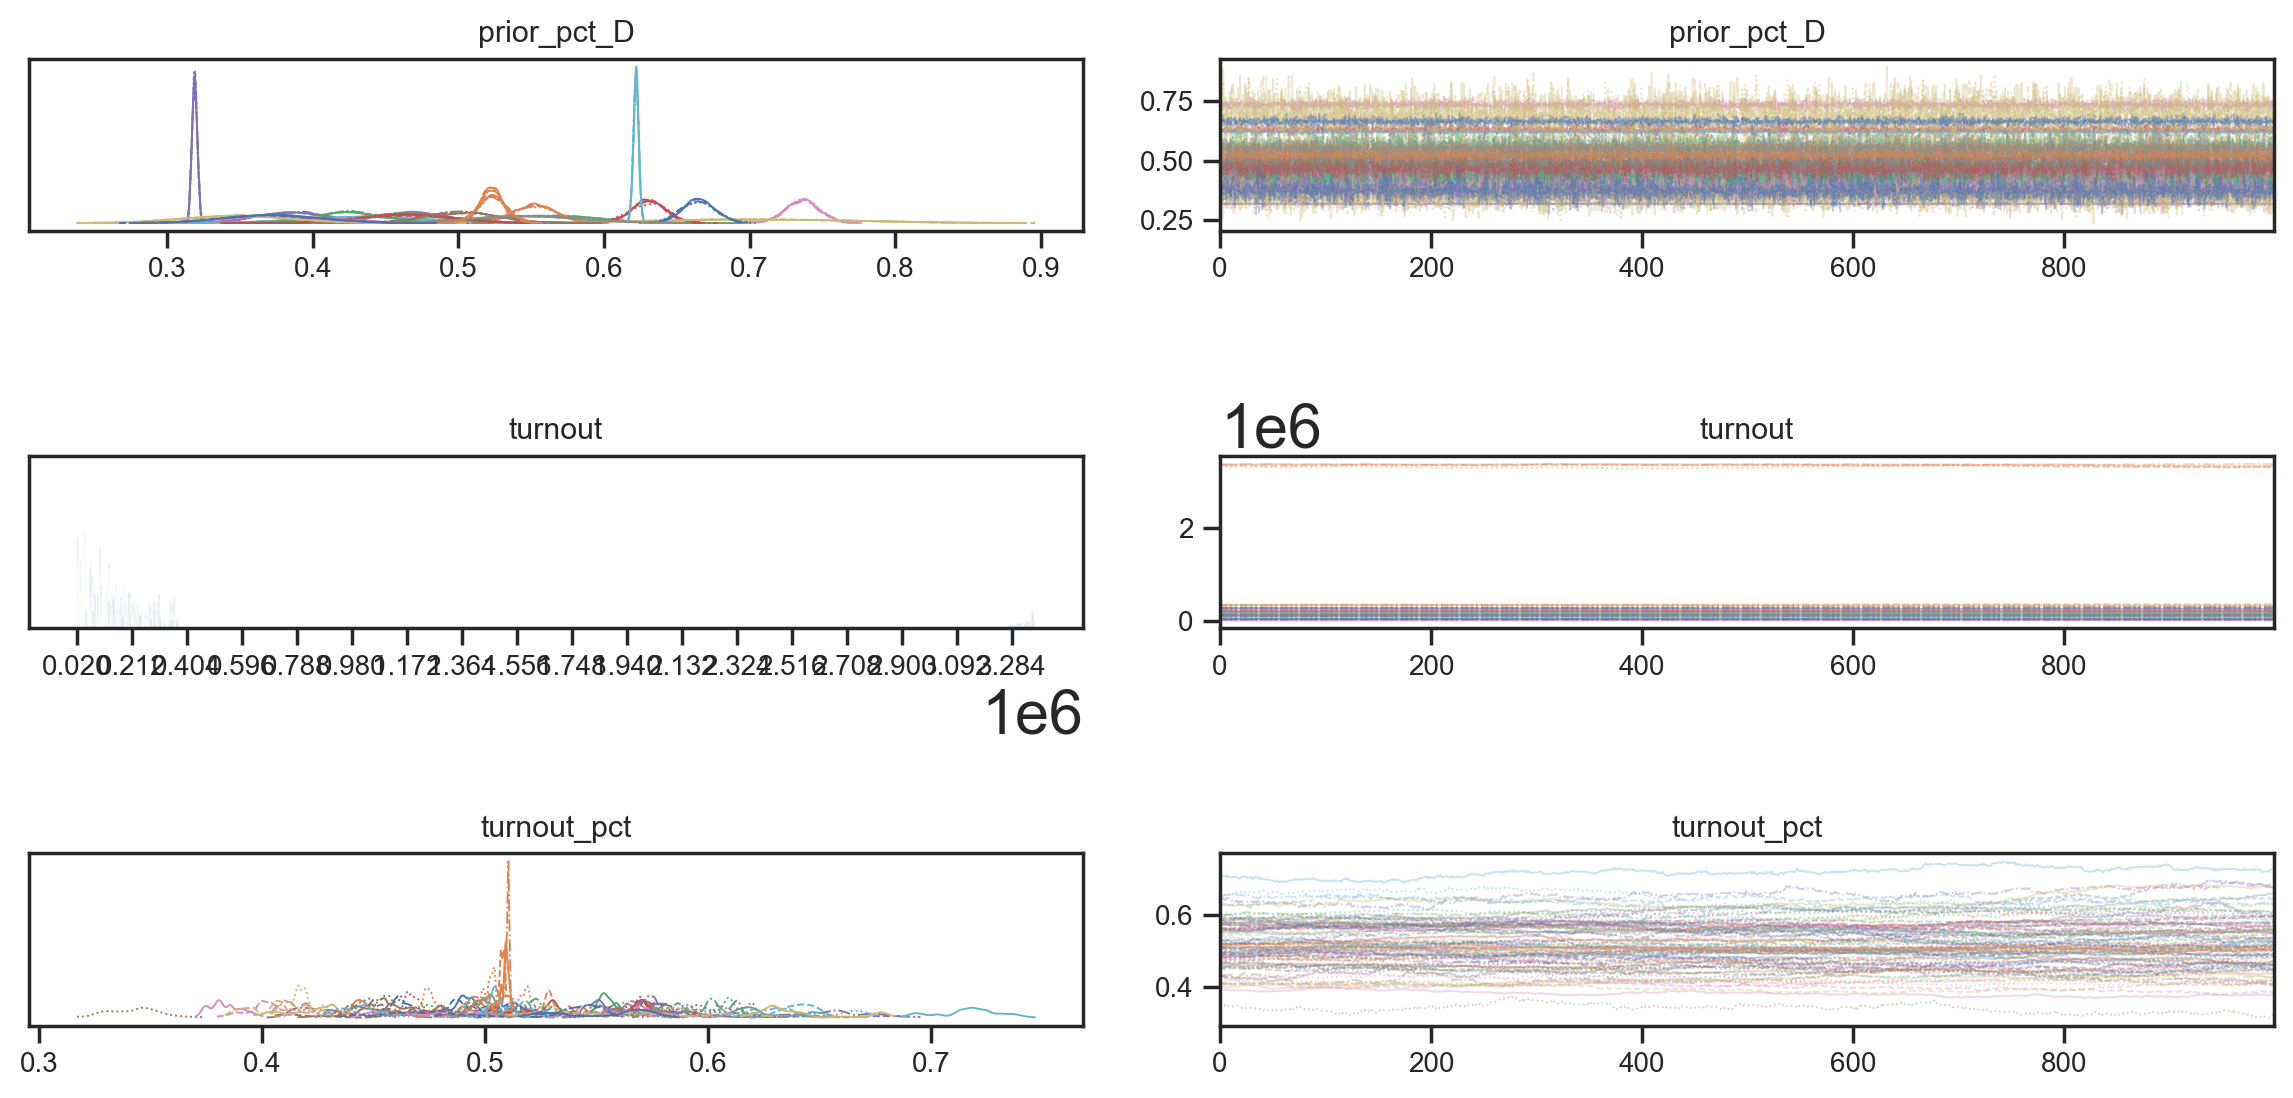

In [38]:
az.plot_trace(idata);
plt.tight_layout()

In [39]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

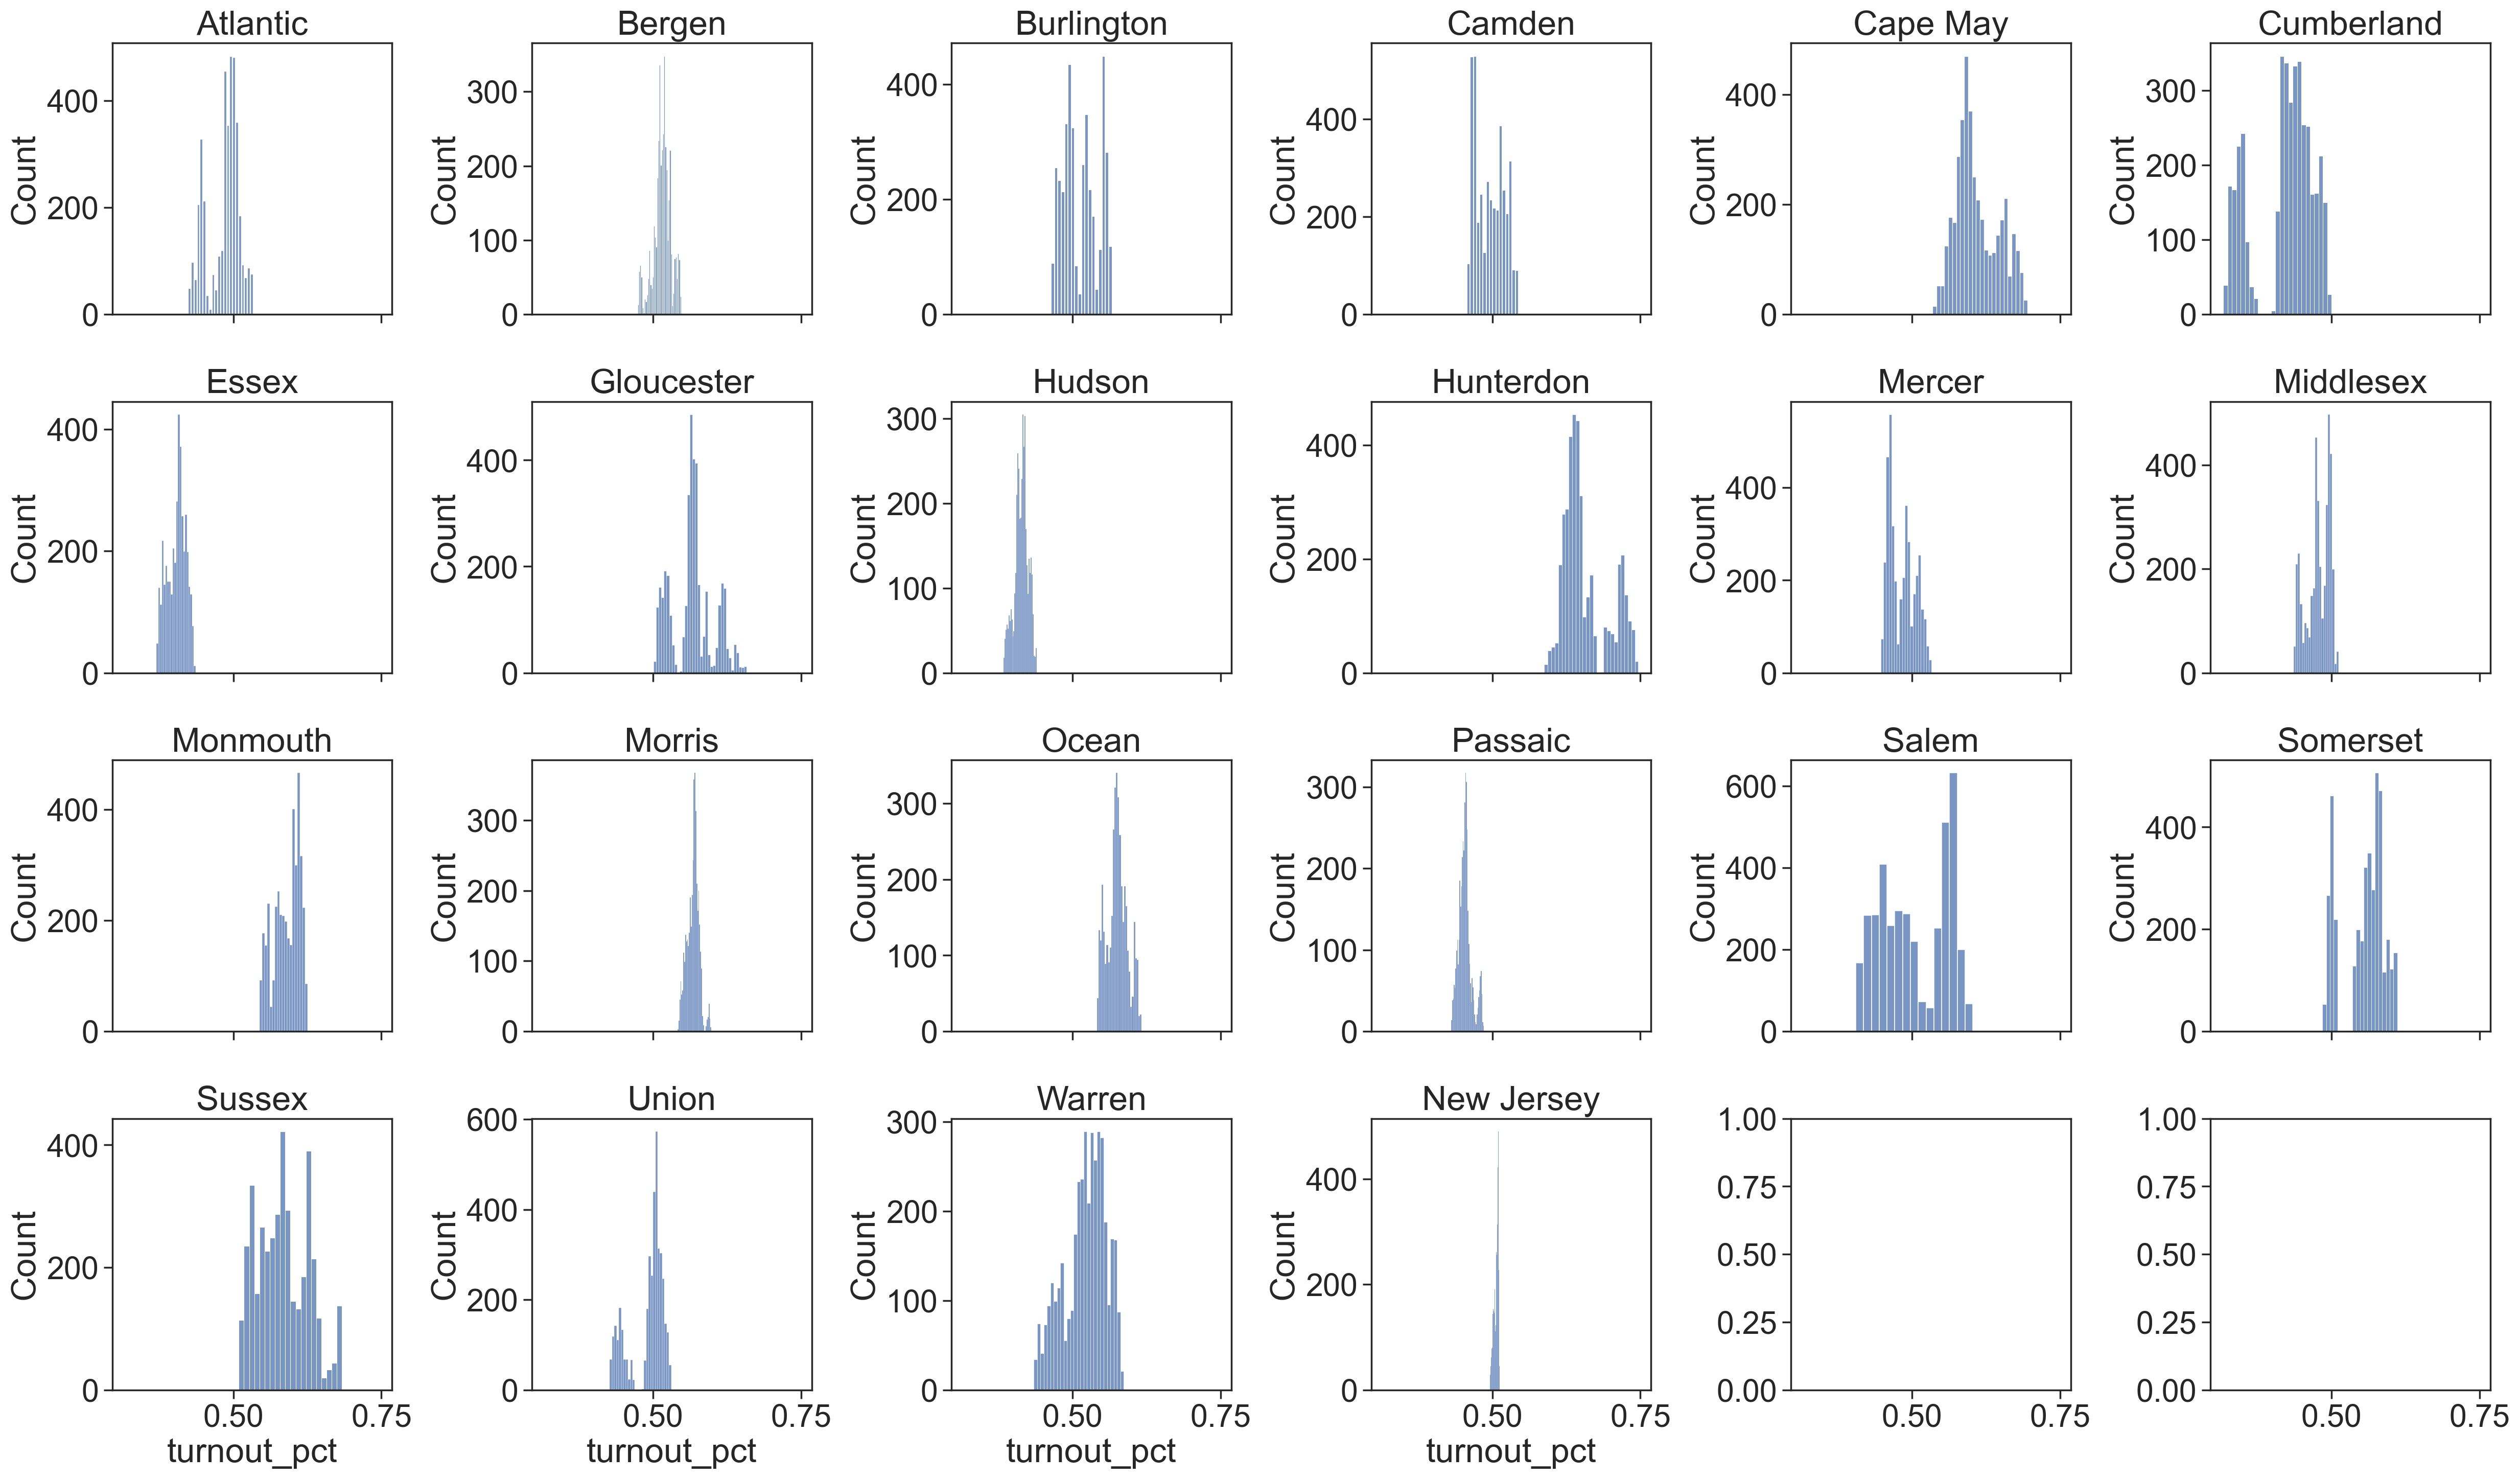

In [40]:
(fig, axs) = plt.subplots(4, 6, sharex=True, sharey=False)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post = idata.posterior.sel(county=c)["turnout_pct"].stack(sample=("chain", "draw"))
    sns.histplot(x=post, ax=ax)
    ax.set_title(str(c.values))

plt.tight_layout()

In [41]:
rows = []
for c in idata.posterior.coords["county"]:
    post = idata.posterior.sel(county=c)["turnout"].stack(sample=("chain", "draw"))
    row = {"County" : str(c.values),
           "Pred" : np.mean(post.values).round(0),
           "Lower" : np.quantile(post.values, 0.025).round(0),
           "Upper" : np.quantile(post.values, 0.975).round(0)}
    rows.append(row)
pandas.DataFrame(rows)

,County,Pred,Lower,Upper
0,Atlantic,98224.0,87686.0,107112.0
1,Bergen,348406.0,323243.0,367412.0
2,Burlington,188173.0,171931.0,205454.0
3,Camden,192054.0,179118.0,208426.0
4,Cape May,46477.0,42242.0,51966.0
5,Cumberland,40208.0,31385.0,46858.0
6,Essex,227864.0,211105.0,242258.0
7,Gloucester,128471.0,115411.0,145000.0
8,Hudson,175832.0,165019.0,184141.0
9,Hunterdon,69898.0,64467.0,78213.0


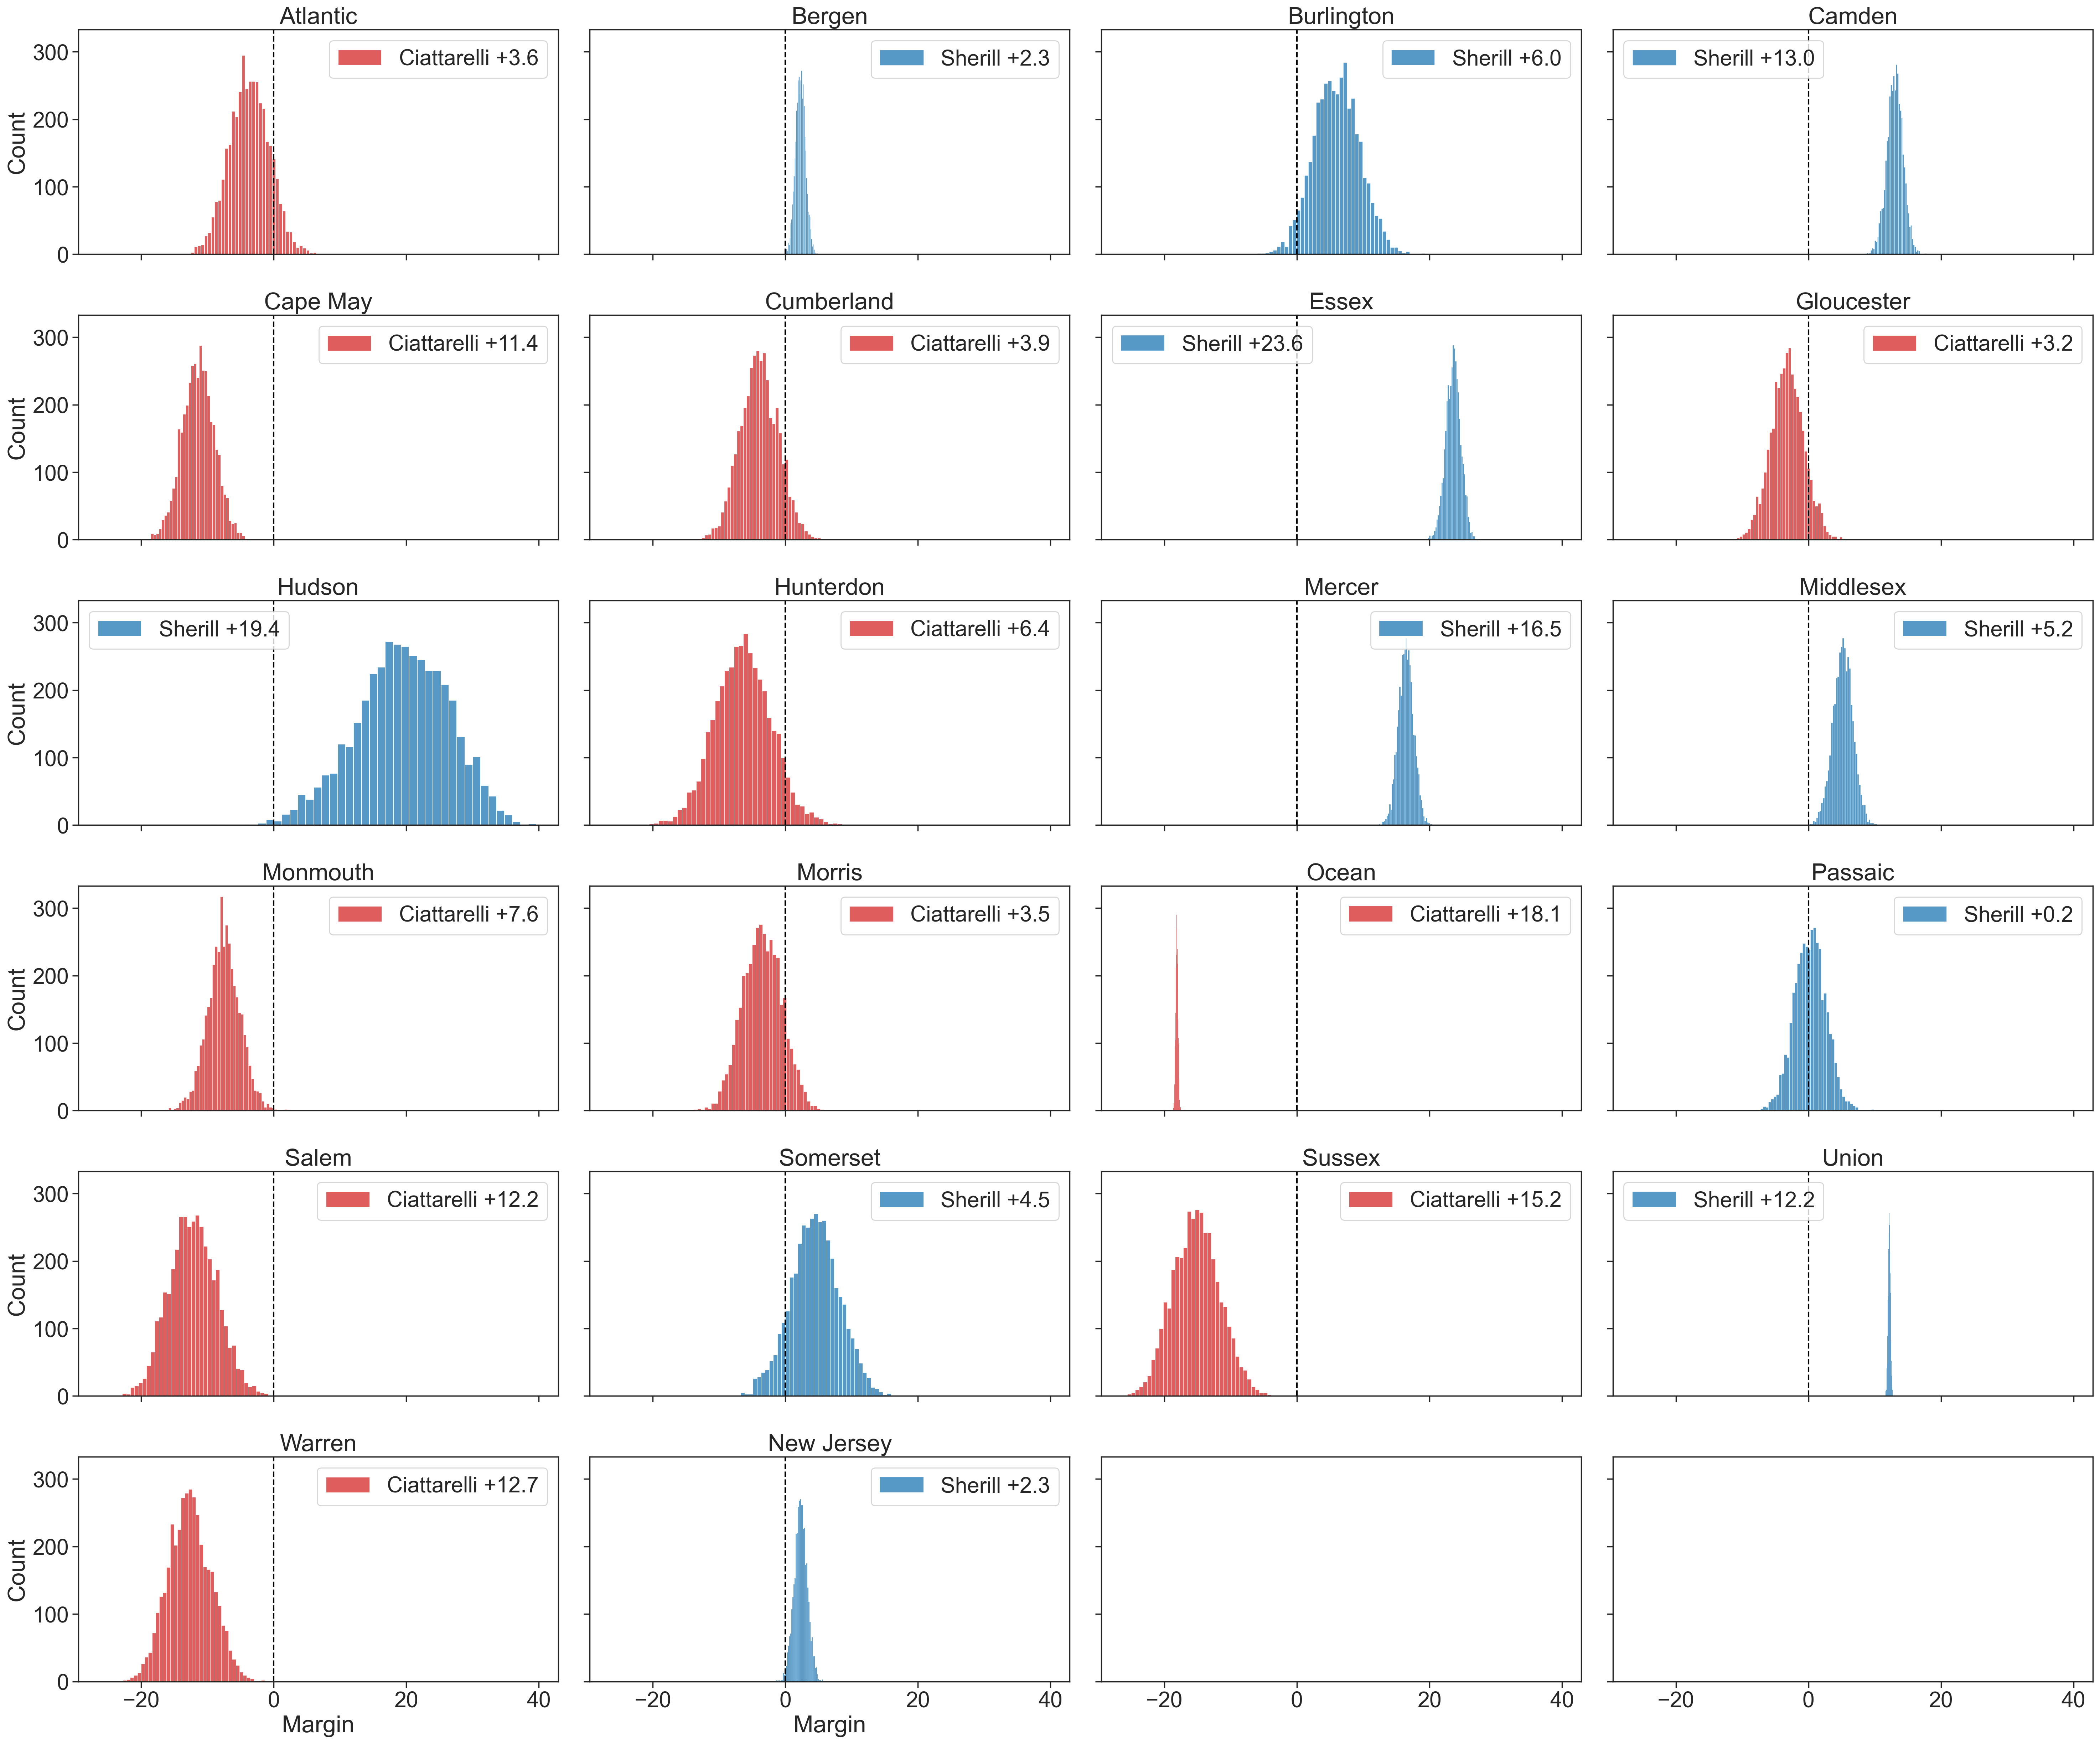

In [42]:
rows = []
(fig, axs) = plt.subplots(6, 4, sharex=True, sharey=True)
fig.set_size_inches(30, 25)

for (c, ax) in zip(idata.posterior.coords["county"], axs.flatten()):
    post = idata.posterior.sel(county=c)["prior_pct_D"].stack(sample=("chain", "draw"))
    margin = (post - 0.5) * 100
    row = {"County" : str(c.values),
           "Pred" : np.mean(margin.values),
           "Lower" : np.quantile(margin.values, 0.025),
           "Upper" : np.quantile(margin.values, 0.975)}
    rows.append(row)
    mean_margin = np.mean(margin.values).mean()

    if mean_margin > 0:
        sns.histplot(x=margin, ax=ax, color="tab:blue", label=f"Sherill +{np.round(mean_margin, 1)}")
    else:
        sns.histplot(x=margin, ax=ax, color="tab:red", label=f"Ciattarelli +{np.round(mean_margin, 1) * -1}")
    
    ax.set_title(str(c.values))
    ax.set_xlabel("Margin")
    ax.legend()
    ax.axvline(0, linestyle="--", color="black")

plt.tight_layout()

In [43]:
pandas.DataFrame(rows).round(1)

,County,Pred,Lower,Upper
0,Atlantic,-3.6,-9.4,2.3
1,Bergen,2.3,0.8,3.8
2,Burlington,6.0,-0.5,12.8
3,Camden,13.0,10.6,15.4
4,Cape May,-11.4,-16.2,-6.7
5,Cumberland,-3.9,-9.5,1.7
6,Essex,23.6,21.4,25.7
7,Gloucester,-3.2,-8.1,1.8
8,Hudson,19.4,4.7,32.2
9,Hunterdon,-6.4,-14.7,2.1
